# EDA

Exploración de datos del dataset simulado.

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config" / "baseline_room.yaml").is_file():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "config" / "baseline_room.yaml").is_file():
    raise FileNotFoundError("Ejecuta el notebook desde la raíz del repo o define REPO_ROOT.")

SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ble_indoor.settings import ProjectConfig, ProjectLayout
from ble_indoor.simulation.trace_loader import load_training_trace

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5.5)

layout = ProjectLayout(REPO_ROOT)
cfg = ProjectConfig.load(layout.default_config_path())
csv_path = layout.resolve_repo_path(cfg.training_data.training_trace_csv)
df = load_training_trace(csv_path, cfg.environment, cfg.spatial_zones)

rssi_cols = [f"rssi_{g}" for g in cfg.environment.gateway_ids]
missing_dbm = float(cfg.trajectory.missing_rssi_dbm)
room_w, room_h = cfg.environment.room.width_m, cfg.environment.room.height_m

print("Filas:", len(df), "| CSV:", csv_path)
print("Gateways:", list(cfg.environment.gateway_ids))
print("Zonas (nx×ny):", cfg.spatial_zones.nx, "×", cfg.spatial_zones.ny, "→", cfg.spatial_zones.n_zones, "clases")
df.head()

## 1. Cobertura espacial y sesgo por zona

Huecos en el mapa

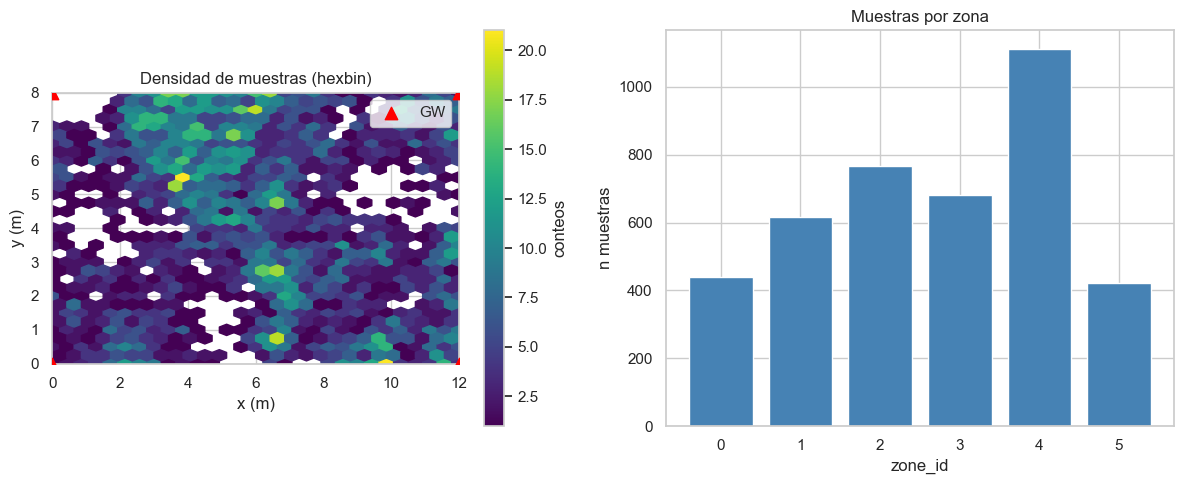

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
hb = ax.hexbin(df["x_m"], df["y_m"], gridsize=28, cmap="viridis", mincnt=1)
ax.set_xlim(0, room_w)
ax.set_ylim(0, room_h)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Densidad de muestras (hexbin)")
plt.colorbar(hb, ax=ax, label="conteos")

gw = cfg.environment.gateway_positions_m()
ax.scatter(gw[:, 0], gw[:, 1], c="red", s=80, zorder=5, marker="^", label="GW")
ax.legend(loc="upper right")

zc = df["zone_id"].value_counts().sort_index()
axes[1].bar(zc.index.astype(str), zc.values, color="steelblue")
axes[1].set_xlabel("zone_id")
axes[1].set_ylabel("n muestras")
axes[1].set_title("Muestras por zona")
plt.tight_layout()
plt.show()

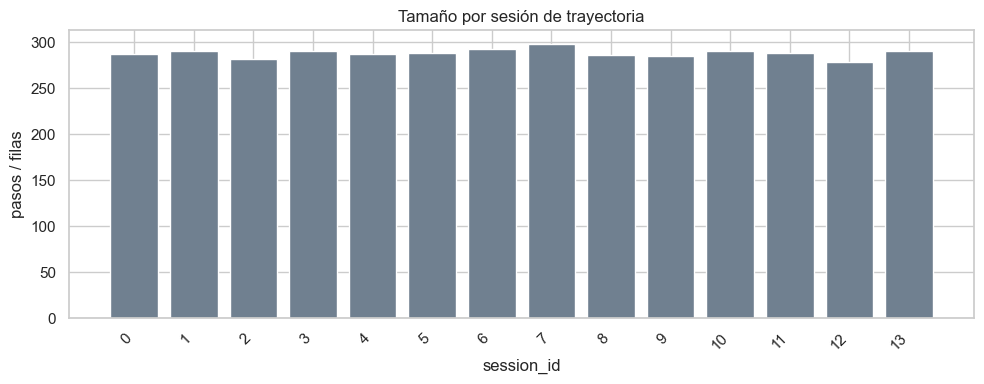

In [3]:
if "session_id" in df.columns:
    sc = df["session_id"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(sc.index.astype(str), sc.values, color="slategray")
    ax.set_xlabel("session_id")
    ax.set_ylabel("pasos / filas")
    ax.set_title("Tamaño por sesión de trayectoria")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columna session_id")

## 2. RSSI — histogramas por gateway

Forma de la distribución: ruido, saturación, colas; comparar con el sentinel de no-recepción.

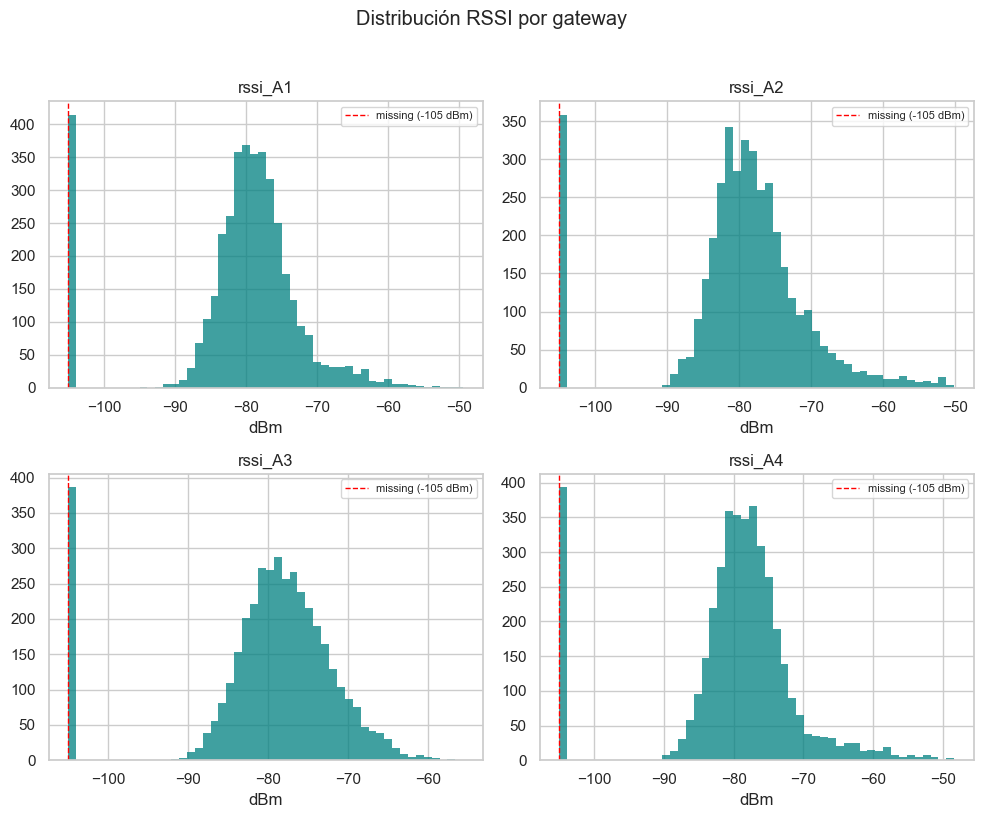

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, col in zip(axes, rssi_cols):
    ax.hist(df[col], bins=50, color="teal", alpha=0.75, edgecolor="none")
    ax.axvline(missing_dbm, color="red", linestyle="--", linewidth=1, label=f"missing ({missing_dbm:g} dBm)")
    ax.set_title(col)
    ax.set_xlabel("dBm")
    ax.legend(fontsize=8)
plt.suptitle("Distribución RSSI por gateway", y=1.02)
plt.tight_layout()
plt.show()

## 3. Correlación entre gateways

Modelos basados en distancias en el espacio RSSI pueden ser sensibles a escala.

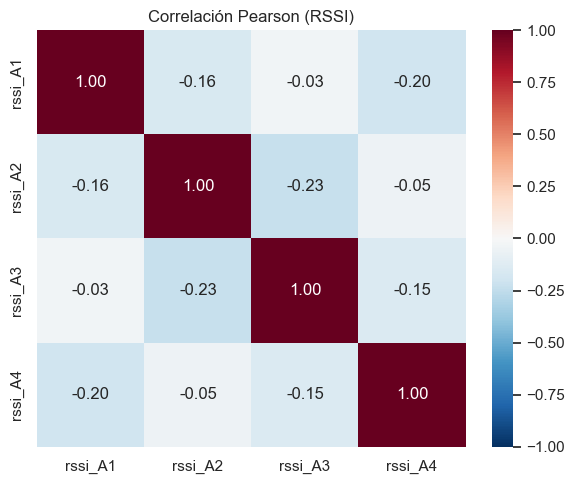

In [5]:
corr = df[rssi_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación Pearson (RSSI)")
plt.tight_layout()
plt.show()

## 4. Valores sentinel / visibilidad

Fracción de lecturas en o cerca del valor `missing_rssi_dbm` y relación con `n_visible` (si existe).

Filas con ≥1 RSSI en/sentinel missing: 1551 (38.4%)


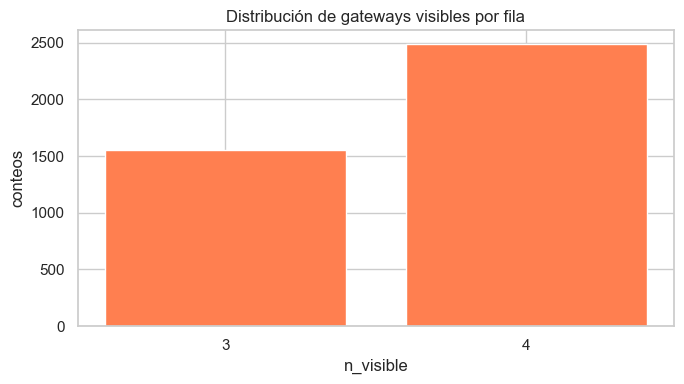

In [6]:
at_missing = (df[rssi_cols] <= missing_dbm + 0.5).sum(axis=1)
print("Filas con ≥1 RSSI en/sentinel missing:", int((at_missing > 0).sum()), f"({100 * (at_missing > 0).mean():.1f}%)")

if "n_visible" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    vc = df["n_visible"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="coral")
    ax.set_xlabel("n_visible")
    ax.set_ylabel("conteos")
    ax.set_title("Distribución de gateways visibles por fila")
    plt.tight_layout()
    plt.show()
else:
    print("Sin columna n_visible")

## 5. RSSI vs distancia a cada gateway

Sanidad del modelo de canal: tendencia monótona aproximada (más lejos indica RSSI más bajo), con dispersión por ruido.

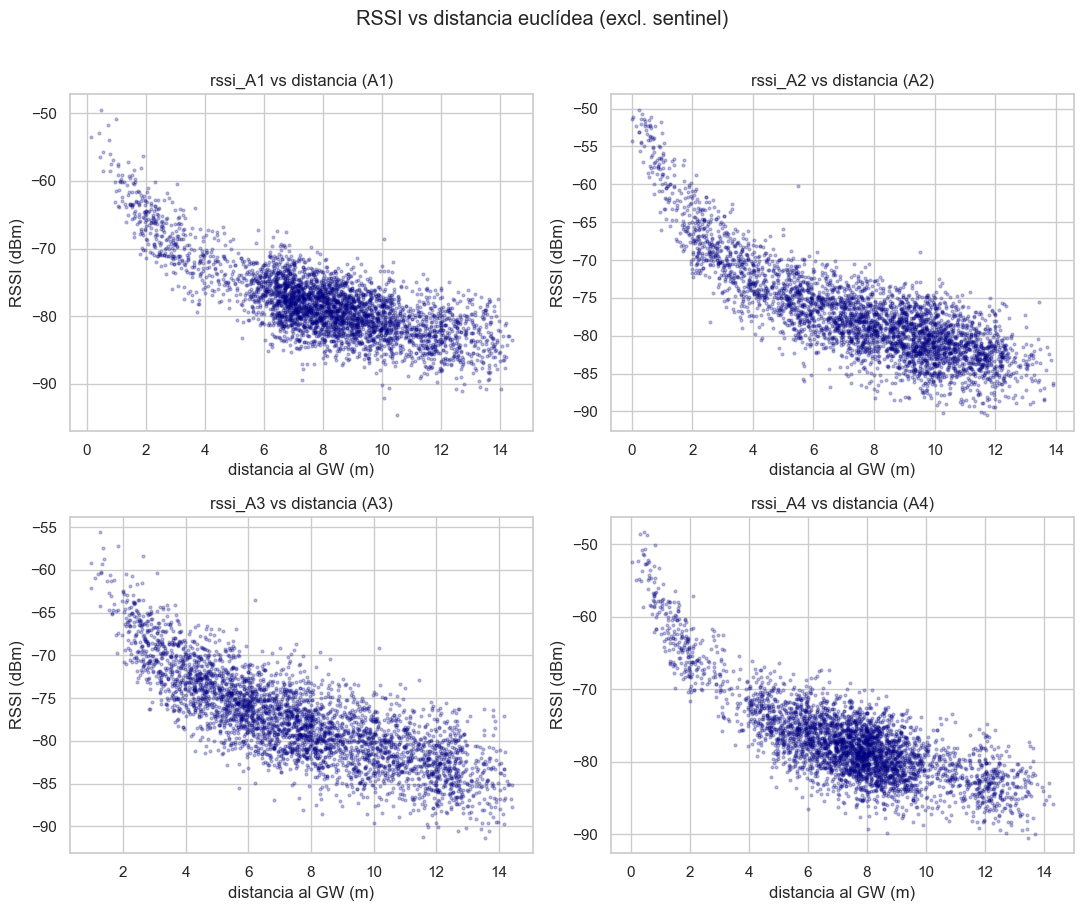

In [7]:
xy = df[["x_m", "y_m"]].to_numpy(dtype=np.float64)
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, col, gw in zip(axes, rssi_cols, cfg.environment.gateways):
    gxy = np.array([[gw.x_m, gw.y_m]], dtype=np.float64)
    d = np.linalg.norm(xy - gxy, axis=1)
    m = df[col].to_numpy() > missing_dbm + 0.5
    ax.scatter(d[m], df.loc[m, col], s=4, alpha=0.25, c="navy")
    ax.set_xlabel("distancia al GW (m)")
    ax.set_ylabel("RSSI (dBm)")
    ax.set_title(f"{col} vs distancia ({gw.id})")

plt.suptitle("RSSI vs distancia euclídea (excl. sentinel)", y=1.01)
plt.tight_layout()
plt.show()

## 6. PCA (2D) del vector RSSI coloreado por zona

Solapamiento de colores, clases difíciles de separar solo con RSSI instantáneo.

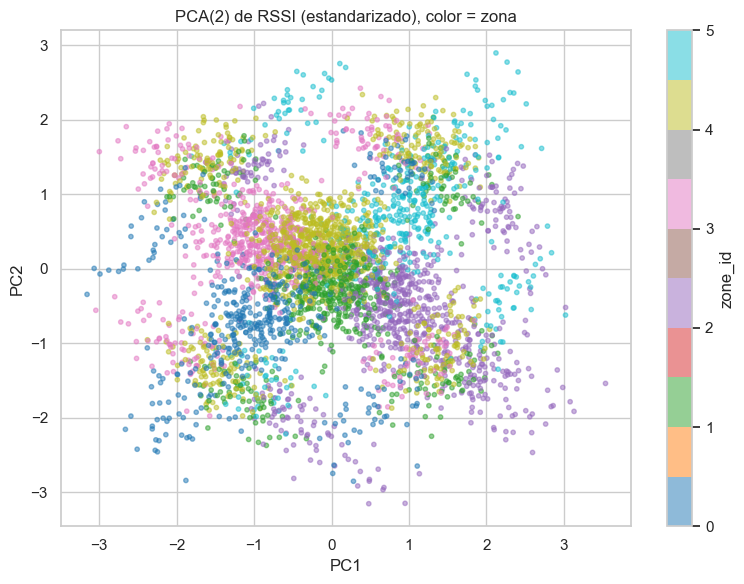

In [8]:
X = df[rssi_cols].to_numpy(dtype=np.float64)
Xz = StandardScaler().fit_transform(X)
Z = PCA(n_components=2, random_state=0).fit_transform(Xz)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=df["zone_id"], cmap="tab10", s=10, alpha=0.5)
plt.colorbar(sc, ax=ax, label="zone_id")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA(2) de RSSI (estandarizado), color = zona")
plt.tight_layout()
plt.show()